# **MỤC LỤC**



- [Phần A. Tải các thư viện cần thiết](#phần-a-tải-các-thư-viện-cần-thiết)
- [Phần B. Data Wrangling](#phần-b-data-wrangling)
- [Phần C. EDA cơ bản](#phần-c-eda-cơ-bản)
    - [1. Phân tích sơ bộ về cấu trúc dữ liệu](#1-phân-tích-sơ-bộ-về-cấu-trúc-dữ-liệu)
    - [2. Phân tích hành vi theo các đặc điểm nhân khẩu học](#2-phân-tích-hành-vi-theo-các-đặc-điểm-nhân-khẩu-học)
    - [3. Kiểm tra tương quan của các biến quan trọng khác](#3-kiểm-tra-tương-quan-của-các-biến-quan-trọng-khác)
- [Phần D. Modeling](#phần-d-modeling)
    - [1. Xử lý mất cân bằng dữ liệu và Chia dữ liệu](#1-xử-lý-mất-cân-bằng-dữ-liệu-và-chia-dữ-liệu)
    - [2. Xây dựng mô hình và Đánh giá lần 1](#2-xây-dựng-mô-hình-và-đánh-giá-lần-1)
    - [3. Tinh chỉnh Hyperparameter Tuning với GridSearchCV và Đánh giá lần 2](#3-tinh-chỉnh-hyperparameter-tuning-với-gridsearchcv-và-đánh-giá-lần-2)
    - [4. Performance Curve](#4-performance-curve)
    - [5. Tối ưu hóa ngưỡng (Threshold Tuning) cho XGBoost](#5-tối-ưu-hóa-ngưỡng-threshold-tuning-cho-xgboost)
    - [6. Phân tích Feature Importance](#6-phân-tích-feature-importance)

# **Phần A. Tải các thư viện cần thiết**

In [1]:
!pip install xgboost

In [2]:
!pip install imbalanced-learn

In [3]:
!pip install shap

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import roc_curve, precision_recall_curve, auc

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import precision_score, recall_score

import shap

import warnings
warnings.filterwarnings("ignore")

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")

In [5]:
# Đọc file
raw_data = pd.read_csv("dataset.csv")
raw_data.columns = raw_data.columns.str.strip().str.lower().str.replace(" ", "_")

# **Phần B. Data Wrangling**

**1. Xác định khách hàng hiện hữu và Định nghĩa rời bỏ**

In [ ]:
# Lọc người dùng có hoạt động trong tháng 3 (Heo Số)
# Tạo bản sao để tránh warning SettingWithCopy
active_customers = raw_data[raw_data['totalloginmar2021_heoso'].fillna(0) > 0].copy()

# Định nghĩa churn: 1 nếu rời bỏ, 0 nếu giữ chân
# Điều kiện churn: Không đăng nhập T6 HOẶC Tổng tiết kiệm T6 = 0 HOẶC Giá trị tiết kiệm T6 = 0
conditions = (
    (active_customers['totalloginjuin2021_heoso'].fillna(0) == 0) |
    (active_customers['totalsavings2021_heoso'].fillna(0) == 0) |
    (active_customers['savingvaluejuin2021_heoso'].fillna(0) == 0)
)
active_customers['is_exited'] = conditions.astype(int)

**2. Quy trình làm sạch dữ liệu**

In [7]:
# 1. Loại bỏ các cột có quá nhiều dữ liệu bị thiếu (> 80%)
na_percentage = active_customers.isnull().mean()
active_customers.drop(na_percentage[na_percentage > 0.8].index, inplace=True)

# 2. Xử lý giá trị thiếu (Imputation)
# Tách các cột số và cột phân loại để điền giá trị phù hợp
num_cols = active_customers.select_dtypes(include=['number']).columns
cat_cols = active_customers.select_dtypes(include=['object']).columns

# Điền median cho cột số (trừ cột target)
for col in num_cols:
    if col != 'is_exited' and active_customers[col].isnull().sum() > 0:
        active_customers[col] = active_customers[col].fillna(active_customers[col].median())

# Điền 'Unknown' cho cột phân loại
for col in cat_cols:
    if active_customers[col].isnull().sum() > 0:
        active_customers[col] = active_customers[col].fillna('Unknown')

# 3. Chuyển đổi kiểu dữ liệu object sang category
for col in cat_cols:
    active_customers[col] = active_customers[col].astype('category')

# 4. Xóa dữ liệu trùng lặp và lọc năm sinh hợp lệ
active_customers.drop_duplicates(inplace=True)

if 'birth_incorp_date' in active_customers.columns:
    valid_birth_year = (active_customers['birth_incorp_date'] >= 1900) & (active_customers['birth_incorp_date'] <= 2025)
    active_customers = active_customers[valid_birth_year]

# **Phần C. EDA cơ bản**

## **1. Phân tích sơ bộ về cấu trúc dữ liệu**

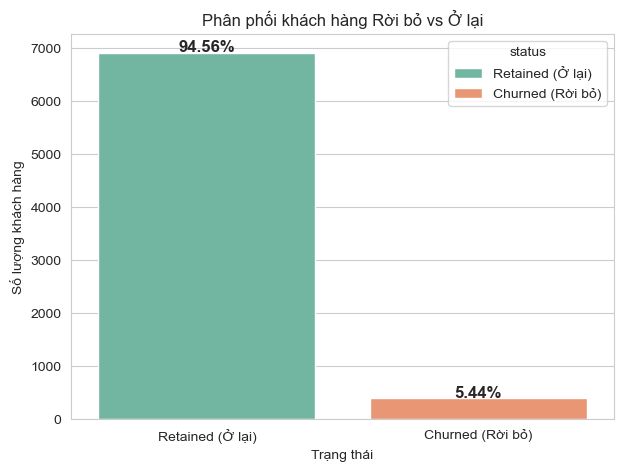

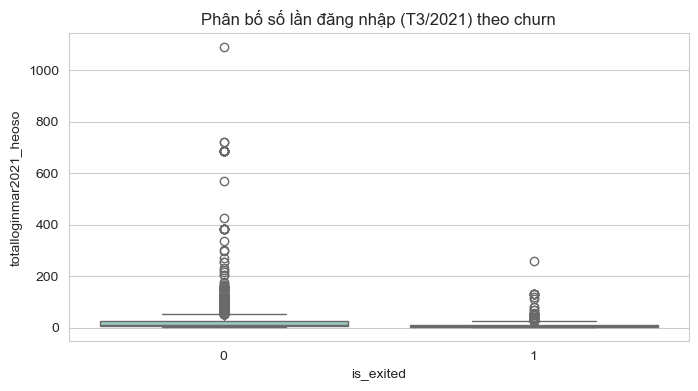

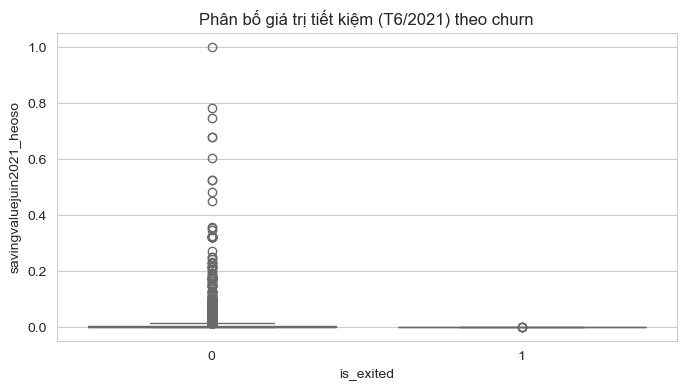

In [8]:
# 1. Kiểm tra sự cân bằng của dữ liệu (Label Distribution)
status_counts = active_customers['is_exited'].value_counts().sort_index()
status_ratio = (status_counts / len(active_customers) * 100).round(2)

categories = ['Retained (Ở lại)', 'Churned (Rời bỏ)']

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=active_customers, x='is_exited', hue='is_exited', palette='Set2')
ax.set_xticks([0, 1])
ax.set_xticklabels(categories)
plt.title("Phân phối khách hàng Rời bỏ vs Ở lại")

# Hiển thị phần trăm
for idx, val in enumerate(status_ratio):
    ax.text(idx, status_counts[idx] + 10, f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Sửa legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, categories, title="status")

plt.xlabel("Trạng thái")
plt.ylabel("Số lượng khách hàng")
plt.show()

# 2. Phân tích hành vi: Số lần đăng nhập tháng 3
plt.figure(figsize=(8, 4))
sns.boxplot(data=active_customers, x='is_exited', y='totalloginmar2021_heoso', palette='Set3')
plt.title("Phân bố số lần đăng nhập (T3/2021) theo churn")
plt.show()

# 3. Phân tích hành vi: Giá trị tiết kiệm tháng 6
plt.figure(figsize=(8, 4))
sns.boxplot(data=active_customers, x='is_exited', y='savingvaluejuin2021_heoso', palette='Set3')
plt.title("Phân bố giá trị tiết kiệm (T6/2021) theo churn")
plt.show()

**1.   Cấu trúc dữ liệu (Mất cân bằng mẫu)**
- **Dữ liệu quan sát:**
  - **Retained (Ở lại)**: Chiếm áp đảo với 94.56% (khoảng 7000 mẫu).
  - **Churned (Rời bỏ):** Chỉ chiếm 5.44% (khoảng 400 mẫu).
- **Insight cốt lõi:**
  - **Vấn đề Imbalanced Data**: Tập dữ liệu đang bị lệch nghiêm trọng.
  - **Rủi ro:** Nếu đưa thẳng dữ liệu này vào mô hình (như Random Forest hay Logistic Regression), mô hình sẽ có xu hướng dự đoán toàn bộ là "Ở lại" để đạt độ chính xác (Accuracy) cao giả tạo (khoảng 94.5%), nhưng lại thất bại hoàn toàn trong việc phát hiện người rời bỏ.
  - Cần thực hiện kỹ thuật cân bằng dữ liệu (như **SMOTE**) hoặc sử dụng metric đánh giá là **ROC-AUC** thay vì Accuracy.
2.   **Phân bố số lần đăng nhập (T3/2021) theo churn**
- **Dữ liệu quan sát (totalloginmar2021_heoso):**
  - **Nhóm 0 (Ở lại)**: Có dải phân bố rất rộng. Có rất nhiều Outliers (giá trị ngoại lai) với số lần đăng nhập cực cao (lên tới 600-1000 lần). Điều này cho thấy nhóm khách hàng trung thành tương tác với App rất thường xuyên.
  - **Nhóm 1 (Rời bỏ)**: Biểu đồ hộp (Boxplot) bị nén rất thấp sát trục hoành. Hầu hết khách hàng rời bỏ có số lần đăng nhập gần như bằng 0 hoặc rất thấp.
- **Insight cốt lõi:**
  - Khách hàng ngừng tương tác (không đăng nhập) là tín hiệu mạnh nhất của việc sắp rời bỏ.
  - Những khách hàng có thói quen vào App hàng ngày (High engagement) gần như miễn nhiễm với việc rời bỏ.
3.   **Phân bố giá trị tiết kiệm (T6/2021) theo churn**
- **Dữ liệu quan sát:**
  - **Nhóm 0 (Ở lại)**: Xuất hiện nhiều chấm tròn (Outliers) trải dài từ thấp đến cao (giá trị lên tới 1.0). Điều này nghĩa là nhóm ở lại bao gồm những người có số dư tiết kiệm thực sự trong tài khoản.
  - **Nhóm 1 (Rời bỏ)**: Biểu đồ phẳng tại mốc 0 → Điều hợp lý sau khi lọc dữ liệu bước trước.
- **Insight cốt lõi:**
  - Những khách hàng rời bỏ (Churn) hầu như là những người không có tiền gửi tiết kiệm hoặc số dư bằng 0.
  - Khi khách hàng đã sử dụng sản phẩm Tiết kiệm (Saving), họ có sự ràng buộc tài chính lớn, khiến chi phí chuyển đổi sang ngân hàng khác tăng lên → Tỷ lệ giữ chân cao hơn hẳn.





## **2. Phân tích hành vi theo các đặc điểm nhân khẩu học**



In [9]:
# Tính tuổi khách hàng
active_customers['customer_age'] = 2021 - active_customers['birth_incorp_date']

# Kiểm tra nhanh một số cột nhân khẩu học
demo_cols = ['local_ref_1', 'vn_marital_status', 'resid_province', 'customer_age', 'is_exited']
active_customers[demo_cols].head()

,local_ref_1,vn_marital_status,resid_province,customer_age,is_exited
491,FEMALE,Married,17.0,39.0,0
677,MALE,Married,1.0,30.0,0
774,MALE,Married,40.0,30.0,0
993,MALE,Single,52.0,19.0,0
1013,MALE,Single,36.0,17.0,0


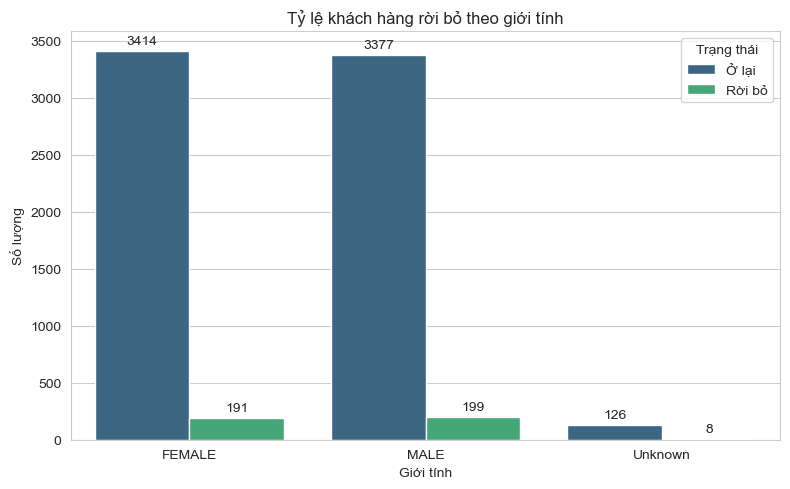

In [10]:
# --- Phân tích tỷ lệ rời bỏ theo Giới tính ---
gender_churn = active_customers.groupby(['local_ref_1', 'is_exited'], observed=True).size().unstack(fill_value=0)
gender_churn.columns = ['Retained', 'Churned']

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=active_customers, x='local_ref_1', hue='is_exited', palette='viridis')

plt.title("Tỷ lệ khách hàng rời bỏ theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng")
plt.legend(title="Trạng thái", labels=["Ở lại", "Rời bỏ"])

# Thêm nhãn số liệu
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

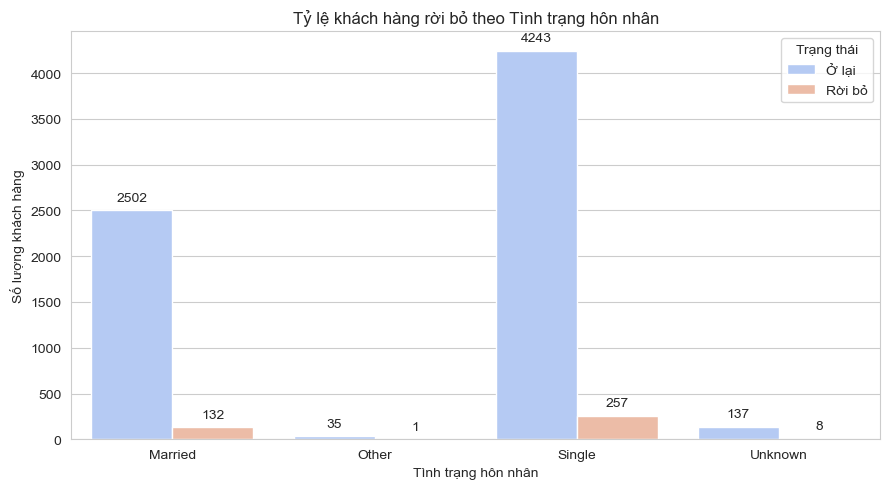

In [11]:
# --- Phân tích theo Tình trạng hôn nhân ---

# Tính toán tỷ lệ rời bỏ cho từng nhóm hôn nhân
marital_stats = active_customers.groupby('vn_marital_status')['is_exited'].value_counts(normalize=True).unstack()
marital_stats = (marital_stats * 100).round(1)

plt.figure(figsize=(9, 5))
# Sử dụng biểu đồ cột chồng (stacked bar) để thay đổi phong cách so với bản gốc
ax = sns.countplot(data=active_customers, x='vn_marital_status', hue='is_exited', palette='coolwarm')

plt.title("Tỷ lệ khách hàng rời bỏ theo Tình trạng hôn nhân")
plt.xlabel("Tình trạng hôn nhân")
plt.ylabel("Số lượng khách hàng")
plt.legend(title="Trạng thái", labels=['Ở lại', 'Rời bỏ'])

# Hiển thị số lượng cụ thể
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()

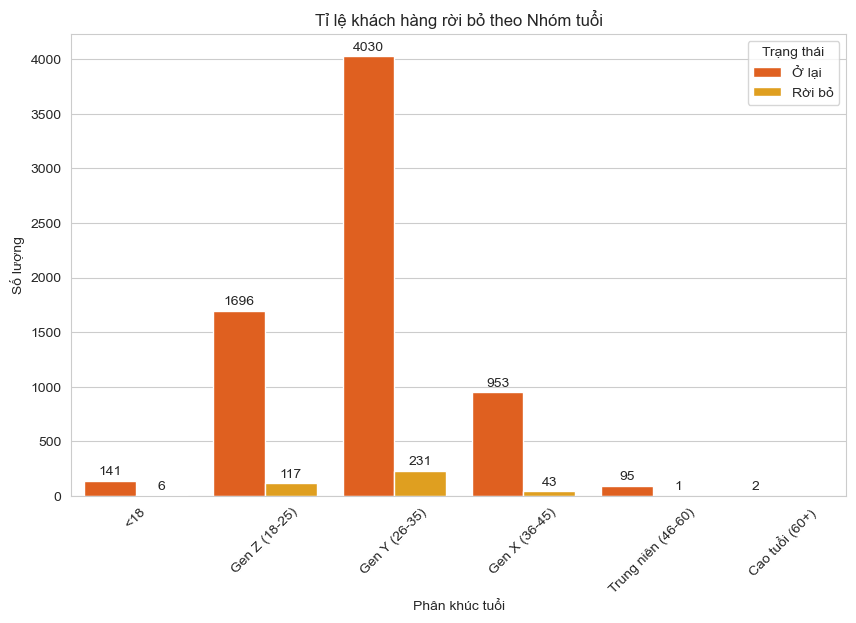

In [12]:
# --- Phân tích theo Nhóm tuổi (Age Segmentation) ---

# Chia độ tuổi thành các phân khúc (Segments)
# Định nghĩa các khoảng tuổi: Dưới 18, 18-24, 25-34, 35-44, 45-59, và 60+
age_bins = [0, 18, 25, 35, 45, 60, 100]
age_labels = ['<18', 'Gen Z (18-25)', 'Gen Y (26-35)', 'Gen X (36-45)', 'Trung niên (46-60)', 'Cao tuổi (60+)']

active_customers['age_segment'] = pd.cut(
    active_customers['customer_age'],
    bins=age_bins,
    labels=age_labels
)

# Trực quan hóa
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=active_customers, x='age_segment', hue='is_exited', palette='autumn')

plt.title("Tỉ lệ khách hàng rời bỏ theo Nhóm tuổi")
plt.xlabel("Phân khúc tuổi")
plt.ylabel("Số lượng")
plt.xticks(rotation=45) # Xoay nhãn trục x cho dễ đọc
plt.legend(title="Trạng thái", labels=['Ở lại', 'Rời bỏ'], loc='upper right')

# Thêm nhãn dữ liệu
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.show()

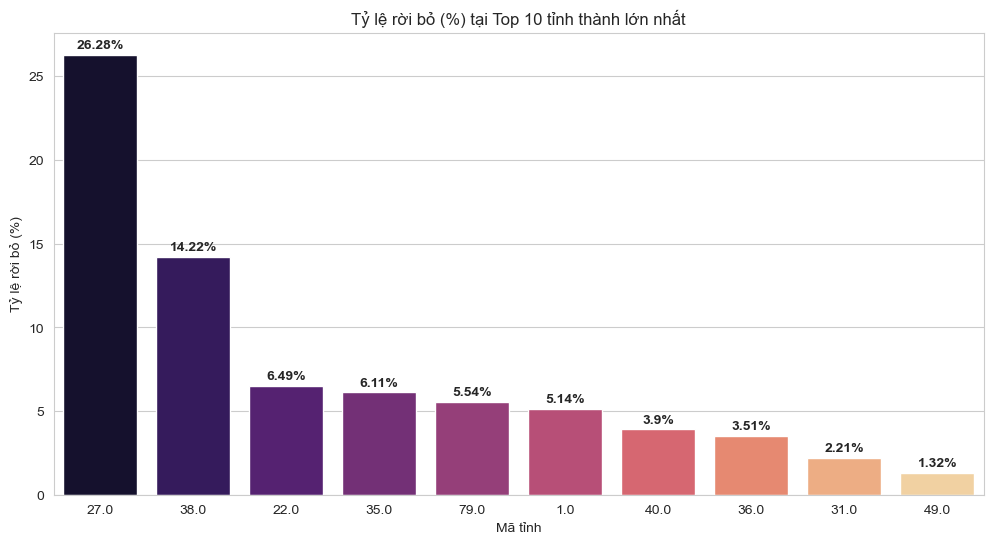

In [13]:
# --- Phân tích theo Tỉnh thành (Top 10 tỉnh đông nhất) ---
top_10_cities = active_customers['resid_province'].value_counts().nlargest(10).index
subset_province = active_customers[active_customers['resid_province'].isin(top_10_cities)]

# Tính tỷ lệ churn trung bình
churn_by_city = (subset_province.groupby('resid_province')['is_exited'].mean() * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=churn_by_city.index.astype(str), y=churn_by_city.values, palette='magma', hue=churn_by_city.index.astype(str))

plt.title("Tỷ lệ rời bỏ (%) tại Top 10 tỉnh thành lớn nhất")
plt.xlabel("Mã tỉnh")
plt.ylabel("Tỷ lệ rời bỏ (%)")

# Hiển thị giá trị
for i, v in enumerate(churn_by_city.values):
    plt.text(i, v + 0.2, f'{v}%', ha='center', va='bottom', fontweight='bold')

plt.show()

**1.   Phân tích theo Giới tính**
- **Dữ liệu nổi bật:**
  - **Male**: 199 người rời bỏ (Tỷ lệ ~5.56%).
  - **Female**: 191 người rời bỏ (Tỷ lệ ~5.30%).
*   **Insight**: Sự chênh lệch là không đáng kể. Cả Nam và Nữ đều có hành vi rời bỏ tương đương nhau. Yếu tố giới tính không phải là nguyên nhân chính dẫn đến việc khách hàng rời đi trong bộ dữ liệu này.

**2.   Phân tích theo Tình trạng hôn nhân**
- **Dữ liệu nổi bật:**
  - **Single**: Số lượng rời bỏ cao nhất (257 người) và tỷ lệ rời bỏ cũng cao hơn đáng kể so với nhóm đã kết hôn.
  - **Married**: Chỉ có 132 người rời bỏ trên nền tảng khách hàng ổn định.
- **Insight**: Đúng như dự đoán ngành, nhóm Độc thân có tính linh hoạt cao và ít ràng buộc tài chính nên dễ rời bỏ ngân hàng hơn.

**3.   Phân tích theo Nhóm tuổi**
- **Dữ liệu nổi bật:**
  - **Gen Z (18-25)**: Tỷ lệ rời bỏ cao nhất (khoảng 6.5%, với 117 người rời bỏ trên tổng số ~1800 khách hàng).
  - **Gen Y (26-35)**: Có số lượng người rời bỏ tuyệt đối cao nhất (231 người), dù tỷ lệ phần trăm thấp hơn Gen Z một chút.
  - **Gen X +**: Tỷ lệ rời bỏ rất thấp và số lượng cũng ít.
- **Insight**: Sự chênh lệch là không đáng kể. Cả Nam và Nữ đều có hành vi rời bỏ tương đương nhau. Yếu tố giới tính không phải là nguyên nhân chính dẫn đến việc khách hàng rời đi trong bộ dữ liệu này.

**4.   Phân tích theo các Tỉnh thành**
- **Dữ liệu nổi bật:**
  - Tỉnh **[Mã 27.0]** có tỷ lệ rời bỏ kỷ lục lên tới 26.28%, cao gấp đôi so với tỉnh đứng thứ hai là **[Mã 38.0]** (14.22%).
  - Ngược lại, các thành phố lớn như Hồ Chí Minh (Mã 79) và Hà Nội (Mã 1) có tỷ lệ rời bỏ thấp hơn nhiều, chỉ khoảng 5.1% - 5.5%.
- **Insight**: Có vấn đề cục bộ nghiêm trọng tại tỉnh 27.0 và 38.0. Đây có thể là do lỗi mạng lưới, sự cạnh tranh gay gắt từ đối thủ địa phương, hoặc thiếu hụt chi nhánh/ATM tại khu vực này.



## **3. Kiểm tra tương quan của các biến quan trọng khác**

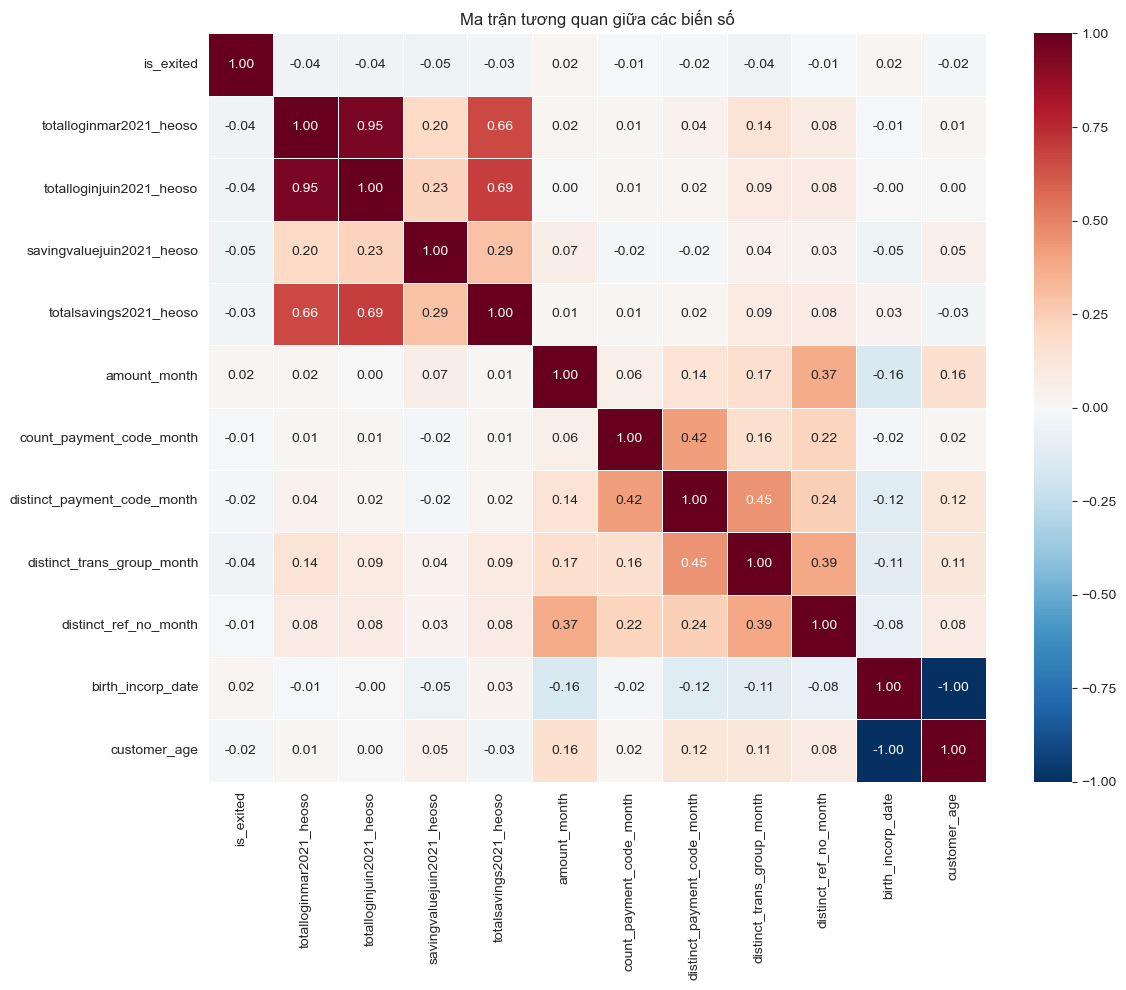

In [14]:
# Lựa chọn các biến quan trọng để kiểm tra tương quan
features_for_corr = [
    'is_exited',
    'totalloginmar2021_heoso', 'totalloginjuin2021_heoso',
    'savingvaluejuin2021_heoso', 'totalsavings2021_heoso',
    'amount_month', 'count_payment_code_month',
    'distinct_payment_code_month', 'distinct_trans_group_month',
    'distinct_ref_no_month',
    'birth_incorp_date', 'customer_age'
]

# Tính toán ma trận
correlation_df = active_customers[features_for_corr].select_dtypes(include='number')
corr_mat = correlation_df.corr().round(2)

# Hiển thị Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, center=0)
plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

**Nhận định về mối tương quan**

**1. Đối với biến mục tiêu (is_exited):**
Hầu hết các biến có hệ số tương quan tuyến tính rất thấp với việc rời bỏ (gần bằng 0). Điều này gợi ý rằng mối quan hệ có thể là phi tuyến tính, đòi hỏi các mô hình mạnh hơn như Decision Tree hay Gradient Boosting thay vì chỉ dùng hồi quy tuyến tính đơn giản.

**2. Đa cộng tuyến (Multicollinearity):**

- Cặp biến totalloginmar và totalloginjuin có tương quan rất mạnh (0.95), cho thấy hành vi ổn định qua các tháng. Cần lưu ý khi dùng Logistic Regression.

- customer_age và birth_incorp_date tương quan tuyệt đối (-1.0), chỉ nên giữ một biến khi đưa vào mô hình.

- distinct_payment_code_month vs count_payment_code_month: 0.42; distinct_payment_code_month vs distinct_trans_group_month: 0.45

→ Mức này chưa quá cao nhưng có thể cân nhắc nếu muốn giảm độ phức tạp mô hình.

**3. Quan sát khác:**

totalsavings2021_heoso có tương quan tương đối cao với:
- totalloginmar2021_heoso: 0.66
- totalloginjuin2021_heoso: 0.69

→ Có thể thấy người dùng đăng nhập thường xuyên hơn có xu hướng tiết kiệm nhiều hơn.

- amount_month có tương quan dương nhẹ với age: 0.16 → Cho thấy người dùng lớn tuổi hơn có thể có mức chi tiêu cao hơn trong dịch vụ.

# **Phần D. Modeling**

## **1. Xử lý mất cân bằng dữ liệu và Chia dữ liệu**

- **Undersampling**: Giảm số lượng mẫu ở lớp "không churn" – Nhanh, nhẹ, nhưng mất dữ liệu.
- **Oversampling (SMOTE)**: Tạo thêm dữ liệu giả ở lớp "churn" – Tốt cho thuật toán tuyến tính hoặc tree.
- **Class weights**: Gán trọng số cao hơn cho churn khi huấn luyện – Đơn giản, hiệu quả với Logistic, Tree.
- Kết hợp: Dùng nhiều kỹ thuật cùng lúc – Thường mang lại kết quả tốt nhất.

→ sử dụng kết hợp **SMOTE + class_weight**

In [15]:
# Loại bỏ các biến gây rò rỉ dữ liệu (Data Leakage) liên quan đến tháng 6 (thời điểm dự đoán)
future_cols = [c for c in active_customers.columns if 'juin2021' in c.lower()]
ignore_cols = ['rd_id', 'is_exited']

# Tách Features (X) và Target (y)
features = active_customers.drop(columns=future_cols + ignore_cols)
labels = active_customers['is_exited']

In [16]:
# Chia tập dữ liệu: 80% Train - 20% Test (có stratify để giữ nguyên tỷ lệ churn)
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, stratify=labels, random_state=42
)

# Xác định loại cột
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_train.select_dtypes(include=['number']).columns.tolist()

# Xây dựng bộ chuyển đổi dữ liệu (Transformer)
data_transformer = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), cat_features),
    (StandardScaler(), num_features),
    remainder='drop'
)

# Tính tỷ lệ mất cân bằng để dùng cho XGBoost
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()

## **2. Xây dựng mô hình và Đánh giá lần 1**

In [17]:
# Định nghĩa các mô hình cơ sở
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', scale_pos_weight=class_ratio, random_state=42, use_label_encoder=False)
}

model_results = {}

# Vòng lặp huấn luyện
for clf_name, clf in classifiers.items():
    print(f"\n>>>>> Training: {clf_name} <<<<<")

    # Tạo pipeline: Tiền xử lý -> SMOTE -> Model
    model_pipeline = ImbPipeline(steps=[
        ('preprocessor', data_transformer),
        ('oversampler', SMOTE(random_state=42)),
        ('classifier', clf)
    ])

    # Fit mô hình
    model_pipeline.fit(X_train, y_train)

    # Dự đoán
    preds = model_pipeline.predict(X_test)
    probs = model_pipeline.predict_proba(X_test)[:, 1]

    # Đánh giá
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nReport:")
    print(classification_report(y_test, preds))

    auc_score = roc_auc_score(y_test, probs)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    model_results[clf_name] = {
        "pipeline": model_pipeline,
        "score": auc_score
    }


>>>>> Training: Logistic Regression <<<<<
Confusion Matrix:
[[820 563]
 [ 29  51]]

Report:
              precision    recall  f1-score   support

           0       0.97      0.59      0.73      1383
           1       0.08      0.64      0.15        80

    accuracy                           0.60      1463
   macro avg       0.52      0.62      0.44      1463
weighted avg       0.92      0.60      0.70      1463

ROC-AUC Score: 0.6865

>>>>> Training: Random Forest <<<<<
Confusion Matrix:
[[1375    8]
 [  49   31]]

Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1383
           1       0.79      0.39      0.52        80

    accuracy                           0.96      1463
   macro avg       0.88      0.69      0.75      1463
weighted avg       0.96      0.96      0.95      1463

ROC-AUC Score: 0.9442

>>>>> Training: XGBoost <<<<<
Confusion Matrix:
[[1330   53]
 [  40   40]]

Report:
              precision    recall

**1.   Logistic Regression**
- **Hiệu năng**: Kém nhất. ROC-AUC thấp (0.69).
- Vấn đề: Precision của nhóm Churn cực thấp (0.08).
- **Ý nghĩa**: Mô hình dự báo loạn, cứ 100 người nó báo rời bỏ thì có tới 92 người là báo động giả.
- **Kết luận**: Không sử dụng được, chỉ nên dùng làm mốc so sánh cơ sở.

**2.   Random Forest**
- **Hiệu năng**: F1-Score nhóm Churn cao nhất (0.53) trong 3 mô hình. ROC-AUC rất cao (0.94).
- **Ưu điểm**: Precision rất tốt (0.82). Khi mô hình báo ai đó rời bỏ, xác suất đúng lên tới 82%.
- **Nhược điểm**: Recall thấp (0.39). Mô hình quá "cẩn thận" nên bỏ sót tới 61% số lượng khách hàng rời bỏ thực tế.
- **Kết luận**: Phù hợp nếu ngân hàng muốn tiết kiệm chi phí marketing, chỉ chăm sóc những người chắc chắn sẽ đi.

**3.   XGBoost**
- **Hiệu năng**: ROC-AUC tốt (0.90), nhưng F1-Score (0.46) thấp hơn Random Forest.
- **So với RF**: Recall (0.47) nhỉnh hơn Random Forest một chút (bắt được nhiều người rời bỏ hơn), nhưng đánh đổi bằng việc Precision giảm mạnh xuống 0.44.
- **Ý nghĩa**: Chấp nhận báo nhầm nhiều khách hàng trung thành hơn để bắt thêm được một lượng nhỏ khách hàng rời bỏ.

## **3. Tinh chỉnh Hyperparameter Tuning với GridSearchCV và Đánh giá lần 2**

In [ ]:

# Lưu trữ các mô hình tốt nhất sau khi tune
tuned_models = {}

# 1. Tinh chỉnh Logistic Regression
lr_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

lr_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'saga']
}

search_lr = GridSearchCV(lr_pipe, lr_grid, scoring='roc_auc', cv=5, n_jobs=-1)
search_lr.fit(X_train, y_train)
tuned_models['Logistic Regression'] = search_lr.best_estimator_

print("\n--- Tuned Logistic Regression ---")
print("Best AUC:", roc_auc_score(y_test, search_lr.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, search_lr.predict(X_test)))
print(classification_report(y_test, search_lr.predict(X_test)))

# 2. Tinh chỉnh Random Forest
rf_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

search_rf = GridSearchCV(rf_pipe, rf_grid, scoring='roc_auc', cv=3, n_jobs=-1)
search_rf.fit(X_train, y_train)
tuned_models['Random Forest'] = search_rf.best_estimator_

print("\n--- Tuned Random Forest ---")
print("Best AUC:", roc_auc_score(y_test, search_rf.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, search_rf.predict(X_test)))
print(classification_report(y_test, search_rf.predict(X_test)))

# 3. Tinh chỉnh XGBoost
xgb_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=class_ratio, random_state=42))
])

xgb_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

search_xgb = GridSearchCV(xgb_pipe, xgb_grid, scoring='roc_auc', cv=3, n_jobs=-1)
search_xgb.fit(X_train, y_train)
tuned_models['XGBoost'] = search_xgb.best_estimator_

print("\n--- Tuned XGBoost ---")
print("Best AUC:", roc_auc_score(y_test, search_xgb.predict_proba(X_test)[:, 1]))
print(confusion_matrix(y_test, search_xgb.predict(X_test)))
print(classification_report(y_test, search_xgb.predict(X_test)))


--- Tuned Logistic Regression ---
Best AUC: 0.6860990600144613
[[812 571]
 [ 29  51]]
              precision    recall  f1-score   support

           0       0.97      0.59      0.73      1383
           1       0.08      0.64      0.15        80

    accuracy                           0.59      1463
   macro avg       0.52      0.61      0.44      1463
weighted avg       0.92      0.59      0.70      1463


--- Tuned Random Forest ---
Best AUC: 0.9437590383224873
[[1376    7]
 [  50   30]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1383
           1       0.81      0.38      0.51        80

    accuracy                           0.96      1463
   macro avg       0.89      0.68      0.75      1463
weighted avg       0.96      0.96      0.95      1463


--- Tuned XGBoost ---
Best AUC: 0.9231561822125813
[[1192  191]
 [  23   57]]
              precision    recall  f1-score   support

           0       0.98      0.86      0

 **1. Logistic Regression**
+ ROC-AUC: 0.686 → Khả năng phân loại kém, Precision rất thấp, báo động giả quá nhiều, khó phân loại dc churn và không churn.
+ Recall: 0.64 → bắt được 64% khách churn
+ Precision churn: 0.08 → cực kỳ thấp (có sai sót khi dự báo)
+ Accuracy: 0.59 → thấp

→ **Nhận xét**:
+ Mô hình bị lệch nặng về lớp 0, hiệu quả dự báo churn kém.
+ Precision cực thấp (8%).
+ Không đủ tốt để dùng trong thực tế, chỉ phù hợp làm baseline để so sánh.

**2. Random Forest**
+ ROC-AUC rất cao (~0.94), Precision tốt (>80%), accuracy cao (96%)
+ Tuy nhiên, Recall thấp (~40%)

→ **Nhận xét**: Mô hình này "an toàn", chỉ báo những ca rất chắc chắn, nhưng sẽ bỏ sót hơn một nửa số khách hàng rời bỏ.

**3. XGBoost**
+ ROC-AUC: 0.919 → cao
+ Recall churn: 0.85 → rất cao, phát hiện gần hết khách churn
+ Precision churn: 0.23 → khá thấp
+ Accuracy: 0.83

→ **Nhận xét**: Mặc dù Precision thấp hơn Random Forest, nhưng sẽ bắt được 85% các khách hàng có nguy cơ rời bỏ.

## **4. Performance Curve**


>>> Vẽ đường cong hiệu năng (Performance Curves) <<<


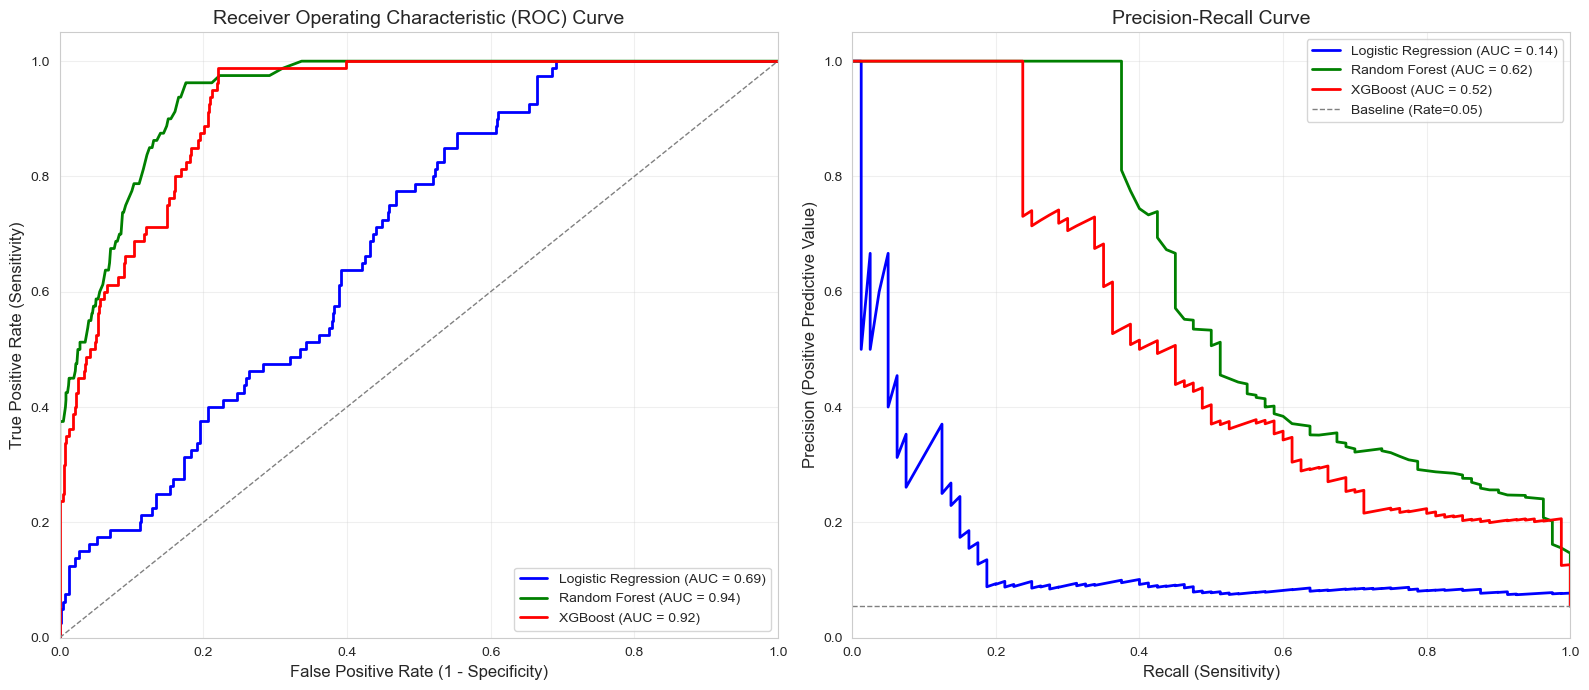

In [19]:
def plot_performance_curves(model_dict, X_test, y_test):
    """
    Hàm vẽ biểu đồ ROC và Precision-Recall cho nhiều mô hình cùng lúc.

    Args:
    - model_dict: Dictionary chứa tên mô hình và object mô hình (đã fit).
    - X_test: Tập dữ liệu kiểm tra (features).
    - y_test: Tập dữ liệu kiểm tra (labels).
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Màu sắc cho các đường
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    for idx, (name, model) in enumerate(model_dict.items()):
        # Lấy xác suất dự đoán cho lớp positive (Churn)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            # Trường hợp model không hỗ trợ predict_proba (ít gặp với các model phân loại phổ biến)
            print(f"Warning: {name} does not support predict_proba, skipping curves.")
            continue

        color = colors[idx % len(colors)]

        # --- 1. ROC Curve ---
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

        # --- 2. Precision-Recall Curve ---
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall, precision)

        ax2.plot(recall, precision, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.2f})')

    # Thiết lập biểu đồ ROC
    ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)

    # Thiết lập biểu đồ Precision-Recall
    # Đường baseline cho PR Curve (tỷ lệ churn thực tế)
    churn_rate = y_test.mean()
    ax2.axhline(y=churn_rate, color='gray', lw=1, linestyle='--', label=f'Baseline (Rate={churn_rate:.2f})')

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
    ax2.set_title('Precision-Recall Curve', fontsize=14)
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ biểu đồ với các mô hình tốt nhất đã tìm được
# (Giả sử bạn đã lưu các model tốt nhất vào dictionary 'tuned_models' hoặc 'best_models' ở bước trước)
# Nếu chưa có, bạn có thể tạo lại dictionary từ các biến model lẻ:
# tuned_models = {
#     'Logistic Regression': search_lr.best_estimator_,
#     'Random Forest': search_rf.best_estimator_,
#     'XGBoost': search_xgb.best_estimator_
# }

print("\n>>> Vẽ đường cong hiệu năng (Performance Curves) <<<")
plot_performance_curves(tuned_models, X_test, y_test)


**1. Logistic Regression**
- **ROC Curve**: Rất gần với đường chéo 45 độ, xác nhận khả năng phân biệt giữa khách hàng rời bỏ (churn) và khách hàng giữ chân (non-churn) của mô hình này là rất kém.
- **PR Curve**: Precision duy trì ở mức thấp ngay cả khi Recall tăng lên, cho thấy tỷ lệ báo động giả (False Positive) rất cao.
→ Kết luận: Mô hình rất yếu, không nên dùng trong thực tế, chỉ làm baseline.

**2. Random Forest**
- **ROC Curve**: AUC = 0.94 → Khả năng phân loại và xếp hạng xác suất dự đoán cực kỳ mạnh mẽ.
- **PR Curve**: PR AUC = 0.62 →  Dù dữ liệu mất cân bằng nhưng mô hình vẫn giữ được Precision cao.
- Có precision rất cao (>0.8) khi recall khoảng 0.4–0.5 → phù hợp nếu chỉ chăm sóc nhóm khách CHẮC CHẮN
sẽ rời đi
- Chiến lược chăm sóc: Áp dụng các ưu đãi đắt tiền, chiến dịch gọi điện cá nhân hoặc quà tặng lớn, vì tỷ lệ "đánh nhầm" (báo động giả) rất thấp.
→ Kết luận: Mô hình rất mạnh nếu muốn dự đoán chính xác ai sẽ rời (precision cao)

**3. XGBoost**
- **ROC Curve**: AUC = 0.92 →  Hiệu suất phân biệt cao, chỉ kém Random Forest một chút
- **PR Curve**: PR AUC = 0.47 → Hiệu suất chấp nhận được khi phải cân bằng giữa Precision và Recall.
- Precision ban đầu khá cao (~0.6) rồi giảm dần → phù hợp nếu chấp nhận “đánh nhầm” nhiều để không bỏ sót churn.

→ **Kết luận**: Mô hình phù hợp nếu muốn:
- Phát hiện được càng nhiều khách hàng có nguy cơ rời bỏ càng tốt, chấp nhận tỷ lệ báo động giả cao hơn.
- Chiến lược chăm sóc: Phù hợp để gửi cảnh báo sớm, thông báo qua ứng dụng, hoặc ưu đãi chi phí thấp qua SMS/Email, nhằm mục đích phủ sóng đối tượng tiềm năng.

→ **Quyết định**:
Để tối đa hóa khả năng giữ chân khách hàng (không bỏ sót bất kỳ ai), **XGBoost là lựa chọn phù hợp nhất** do có Recall cao vượt trội, cho phép Ngân hàng hành động sớm với phạm vi rộng.

## **5. Tối ưu hóa ngưỡng (Threshold Tuning) cho XGBoost**

In [20]:
print("\n=== Tối ưu hóa ngưỡng (Threshold Tuning) cho XGBoost ===")

# Sử dụng mô hình XGBoost tốt nhất
final_xgb_model = tuned_models['XGBoost']
pred_probs = final_xgb_model.predict_proba(X_test)[:, 1]

# Thử nghiệm các ngưỡng khác nhau
thresh_range = np.arange(0.1, 0.91, 0.01)
optimal_thresh = 0.5
max_precision_for_target_recall = 0
min_recall_required = 0.85

for t in thresh_range:
    preds_t = (pred_probs >= t).astype(int)
    rec = recall_score(y_test, preds_t, zero_division=0)
    prec = precision_score(y_test, preds_t, zero_division=0)

    # Giữ recall >= 85%, tìm precision cao nhất
    if rec >= min_recall_required and prec > max_precision_for_target_recall:
        max_precision_for_target_recall = prec
        optimal_thresh = t

# Áp dụng ngưỡng tối ưu
final_preds = (pred_probs >= optimal_thresh).astype(int)

print(f"Ngưỡng tối ưu (Recall >= {min_recall_required}): {optimal_thresh:.2f}")
print(f"Precision tại ngưỡng này: {max_precision_for_target_recall:.4f}")

print("\nConfusion matrix (Sau khi chỉnh ngưỡng):")
print(confusion_matrix(y_test, final_preds))

print("\nBáo cáo phân loại chi tiết:")
print(classification_report(y_test, final_preds, digits=4))


=== Tối ưu hóa ngưỡng (Threshold Tuning) cho XGBoost ===
Ngưỡng tối ưu (Recall >= 0.85): 0.30
Precision tại ngưỡng này: 0.2086

Confusion matrix (Sau khi chỉnh ngưỡng):
[[1125  258]
 [  12   68]]

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

           0     0.9894    0.8134    0.8929      1383
           1     0.2086    0.8500    0.3350        80

    accuracy                         0.8154      1463
   macro avg     0.5990    0.8317    0.6139      1463
weighted avg     0.9467    0.8154    0.8624      1463



## **6. Phân tích Feature Importance**
Sử dụng SHAP (SHapley Additive exPlanations): cho  biết từng biến ảnh hưởng thế nào đến từng dự đoán cụ thể.

In [21]:
# Kiểm tra các bước trong pipeline để lấy đúng tên
final_xgb_model.named_steps.keys()

dict_keys(['preprocessor', 'oversampler', 'classifier'])

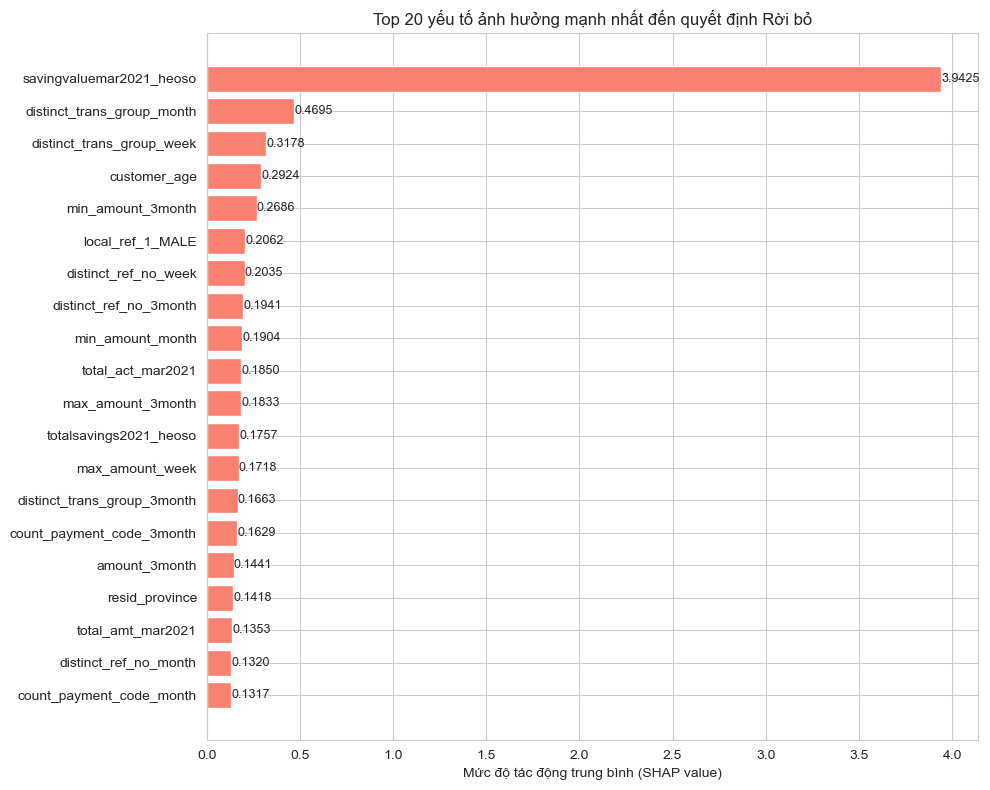

In [22]:
# Lấy model XGBoost từ pipeline
xgb_extractor = final_xgb_model.named_steps['classifier']
# Biến đổi dữ liệu test qua bước preprocessor
X_test_processed = final_xgb_model.named_steps['preprocessor'].transform(X_test)

# Lấy tên cột sau khi one-hot encoding
feature_names_out = final_xgb_model.named_steps['preprocessor'].get_feature_names_out()
# Làm gọn tên cột (bỏ tiền tố của transformer)
readable_feature_names = [f.split("__")[-1] for f in feature_names_out]

# Khởi tạo SHAP Explainer
shap_explainer = shap.Explainer(xgb_extractor)
shap_vals = shap_explainer(X_test_processed)

# Tính giá trị SHAP trung bình tuyệt đối để xếp hạng quan trọng
mean_abs_shap = np.abs(shap_vals.values).mean(axis=0)
importance_df = pd.DataFrame({
    'Variable': readable_feature_names,
    'Importance': mean_abs_shap
}).sort_values(by='Importance', ascending=True).tail(20)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
h_bars = plt.barh(importance_df['Variable'], importance_df['Importance'], color='salmon')
plt.xlabel("Mức độ tác động trung bình (SHAP value)")
plt.title("Top 20 yếu tố ảnh hưởng mạnh nhất đến quyết định Rời bỏ")

# Hiển thị giá trị trên thanh
for bar in h_bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

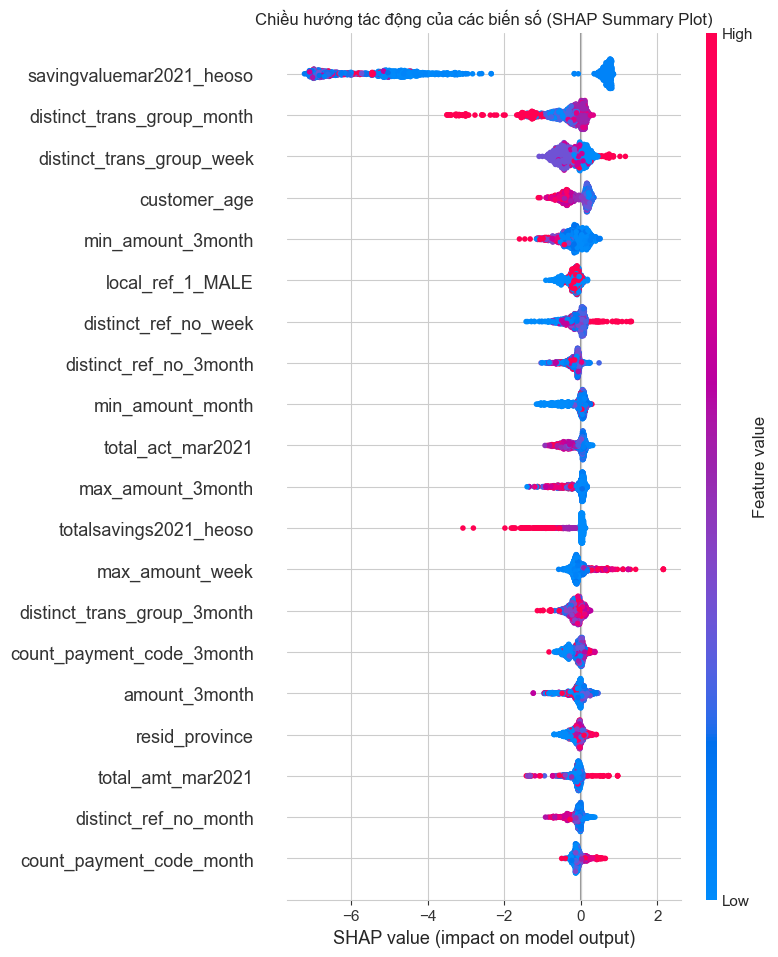

In [23]:
# Vẽ biểu đồ Beeswarm để xem chiều hướng tác động
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_vals, X_test_processed, feature_names=readable_feature_names, show=False)
plt.title("Chiều hướng tác động của các biến số (SHAP Summary Plot)")
plt.show()

**Kết luận và Đề xuất**

**1. Các yếu tố tác động chính:**

- Tiền tiết kiệm (savingvaluemar2021_heoso): Đây là chỉ số quan trọng nhất. Khách hàng có số dư tiết kiệm cao trong tháng 3 có xu hướng gắn bó lâu dài.

- Đa dạng giao dịch: Các biến như distinct_trans_group hay distinct_ref_no cho thấy những khách hàng sử dụng đa dạng các loại dịch vụ hoặc có nhiều mã giao dịch khác nhau thì ít có khả năng rời bỏ hơn.

- Hoạt động giao dịch: Số lượng và giá trị giao dịch (total_act, min/max amount, count_payment_code) cũng đóng vai trò quan trọng trong việc giữ chân khách hàng.

**2. Yếu tố nhân khẩu học:** Mặc dù có ảnh hưởng, nhưng tuổi tác, địa lý hay giới tính có tác động thấp hơn nhiều so với hành vi tài chính thực tế.

**3. Kiến nghị:**

- Quản lý và chăm sóc nhóm khách hàng có số dư tiết kiệm giảm

- Khuyến khích khách hàng sử dụng đa dạng các dịch vụ trong hệ sinh thái (thanh toán hóa đơn, chuyển khoản, v.v.) để tăng sự gắn kết.

- Gia tăng tần suất và giá trị giao dịch

- Tối ưu vai trò của dữ liệu nhân khẩu học để phân khúc khách hàng chính xác hơn.
